Running ramped-T ensemble...
Run 1/10 ...
Run 2/10 ...
Run 3/10 ...
Run 4/10 ...
Run 5/10 ...
Run 6/10 ...
Run 7/10 ...
Run 8/10 ...
Run 9/10 ...
Run 10/10 ...


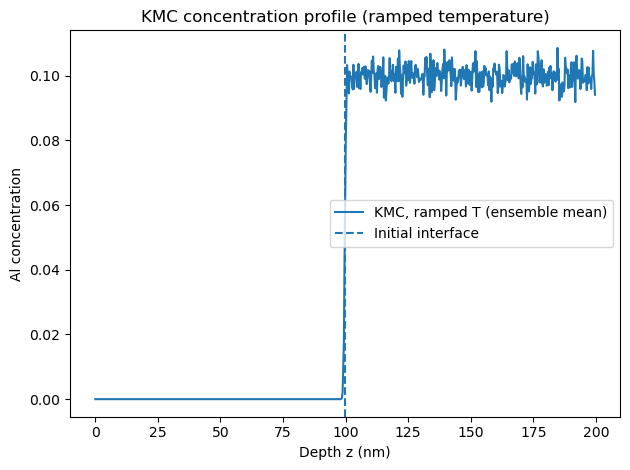

In [1]:
# Task 2.1

import numpy as np
from math import exp, log, sqrt
from scipy.special import erf
import matplotlib.pyplot as plt

# Physical constants and parameters

thickness_total = 200e-9   # m, 100 nm Cu | 100 nm Cu-10%Al
b = 2.54e-10               # m, NN spacing in Cu
R = 8.314                  # J/mol/K
D0 = 1.49e-7               # m^2/s, prefactor
Q = 137100.0               # J/mol, activation energy

# Temperature ramp
Ti = 298.0                 # K
Tf = 600.0                 # K
t_ramp = 10.0              # s, total simulation time
t_max_ramp = t_ramp

# Lattice size
Nz = int(round(thickness_total / b))     # ~200 nm film
Nx = Nz

z_interface = Nz // 2
c_Al_init = 0.10

rng = np.random.default_rng(seed=12345)

# External temperature time grid for ramped case
n_T_steps = 200
dt_T = t_ramp / n_T_steps


""" Helper functions """
# Linear temperature ramp Ti -> Tf over t_ramp
def T_of_t(t):
    if t >= t_ramp:
        return Tf
    return Ti + (Tf - Ti) * t / t_ramp

# Arrhenius diffusion coefficient of Al in Cu
def D_of_T(T):
    return D0 * exp(-Q / (R * T))

# Per-neighbour jump rate ν_ij(T) with D = ν b^2 in 2D.
def nu_of_T(T):
    D = D_of_T(T)
    return D / (b ** 2)

# Initializing occupancy and list of Al atoms
def init_lattice():
    """
    occ : (Nz, Nx) int8 array, 0=Cu, 1=Al
    al_sites : (N_Al, 2) int32 array, each row [z, x]
    """
    occ = np.zeros((Nz, Nx), dtype=np.int8)
    mask = (rng.random((Nz - z_interface, Nx)) < c_Al_init)
    occ[z_interface:, :] = mask.astype(np.int8)

    al_sites = np.argwhere(occ == 1).astype(np.int32)
    return occ, al_sites

# c(z) = fraction of Al along x at each depth z.
def concentration_profile(occ):
    return occ.mean(axis=1)


# Rejection KMC with time-dependent T
def run_kmc_single(t_max, record_times, ramp=True, T_const=None):
    """
    Rejection KMC using only the list of Al atoms.

    - At each event, pick random Al and random direction.
    - If target site is outside film or already Al, do nothing (null event).
    - For constant T (ramp=False): standard KMC with Γ constant in time.
    - For ramp=True: T(t) handled with an external temperature grid, so
      a low-T rate cannot "claim" the whole future.
    """
    occ, al_sites = init_lattice()
    N_al = al_sites.shape[0]

    t = 0.0
    record_times = np.asarray(record_times)
    rec_idx = 0

    profiles = []
    times_out = []

    # Recording initial
    while rec_idx < len(record_times) and t >= record_times[rec_idx]:
        profiles.append(concentration_profile(occ).copy())
        times_out.append(record_times[rec_idx])
        rec_idx += 1

    if N_al == 0:
        return np.array(times_out), np.array(profiles)

    # Ramped-T with external temperature grid

    t_T = 0.0
    t_T_next = min(dt_T, t_max)
    T = T_of_t(t_T)

    while t < t_max:
        nu = nu_of_T(T)
        Gamma = 4.0 * nu * N_al

        if Gamma <= 0.0:
            # No possible jumps: just march to next T-grid boundary
            t = min(t_T_next, t_max)
        else:
            # propose KMC event time
            dt_event = -log(rng.random()) / Gamma

            if t + dt_event > t_T_next:
                # no event in this T-interval: advance to the boundary
                t = t_T_next
            else:
                # event occurs before T changes
                t += dt_event

                # Pick random Al atom
                i_atom = rng.integers(N_al)
                z, x = al_sites[i_atom]

                # Pick random direction: 0=up, 1=down, 2=left, 3=right
                d = rng.integers(4)
                if d == 0:
                    z2, x2 = z - 1, x
                elif d == 1:
                    z2, x2 = z + 1, x
                elif d == 2:
                    z2, x2 = z, (x - 1) % Nx
                else:
                    z2, x2 = z, (x + 1) % Nx

                # Reflecting boundaries in z and blocked-site constraint
                if 0 <= z2 < Nz and occ[z2, x2] == 0:
                    occ[z, x] = 0
                    occ[z2, x2] = 1
                    al_sites[i_atom, 0] = z2
                    al_sites[i_atom, 1] = x2

        # If a temperature-grid boundary is crossed, update T and interval
        if t >= t_T_next and t < t_max:
            t_T = t_T_next
            t_T_next = min(t_T + dt_T, t_max)
            T = T_of_t(t_T)

        # Recording whenever we pass a record time
        while rec_idx < len(record_times) and t >= record_times[rec_idx]:
            profiles.append(concentration_profile(occ).copy())
            times_out.append(record_times[rec_idx])
            rec_idx += 1

    return np.array(times_out), np.array(profiles)


# Ensemble driver
def run_kmc_ensemble(n_runs, t_max, record_times, ramp=True, T_const=None):
    n_times = len(record_times)
    profiles_all = np.zeros((n_runs, n_times, Nz))

    for i in range(n_runs):
        print(f"Run {i+1}/{n_runs} ...")
        times, profiles = run_kmc_single(t_max, record_times, ramp, T_const)
        if profiles.shape[0] != n_times:
            last = profiles[-1]
            full = np.zeros((n_times, Nz))
            full[:profiles.shape[0]] = profiles
            full[profiles.shape[0]:] = last
            profiles = full
        profiles_all[i] = profiles

    return record_times, profiles_all.mean(axis=0), profiles_all


# Time-dependent temperature ramp: run and plot
if __name__ == "__main__":
    record_times_ramp = np.linspace(0.0, t_max_ramp, 21)
    n_runs_ramp = 10

    print("Running ramped-T ensemble...")
    times_ramp, prof_mean_ramp, _ = run_kmc_ensemble(
        n_runs=n_runs_ramp,
        t_max=t_max_ramp,
        record_times=record_times_ramp,
        ramp=True,
        T_const=None
    )

    z_indices = np.arange(Nz)
    z_physical_nm = z_indices * b * 1e9

    plt.figure()
    plt.plot(z_physical_nm, prof_mean_ramp[-1],
             label="KMC, ramped T (ensemble mean)")
    plt.axvline(z_interface * b * 1e9, linestyle="--", label="Initial interface")
    plt.xlabel("Depth z (nm)")
    plt.ylabel("Al concentration")
    plt.title("KMC concentration profile (ramped temperature)")
    plt.legend()
    plt.tight_layout()
    plt.show()


Running KMC to collect snapshots...


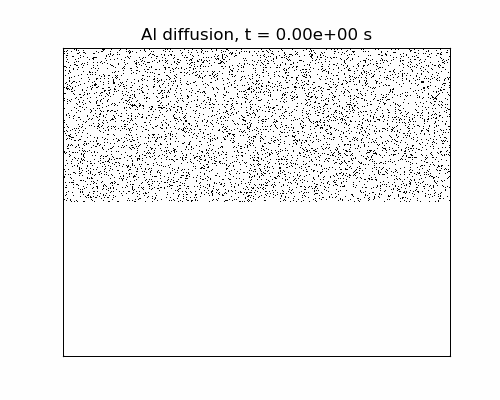

In [2]:
def run_kmc_single_snapshots(t_max, snapshot_times, ramp=True, T_const=None):
    """
    KMC with the same physics as run_kmc_single, but returns full
    lattice snapshots occ[z, x] instead of depth-averaged profiles.
    """
    occ, al_sites = init_lattice()
    N_al = al_sites.shape[0]

    t = 0.0
    snapshot_times = np.asarray(snapshot_times)
    snap_idx = 0

    snapshots = []
    times_out = []

    # Recording initial state if requested
    while snap_idx < len(snapshot_times) and t >= snapshot_times[snap_idx]:
        snapshots.append(occ.copy())
        times_out.append(snapshot_times[snap_idx])
        snap_idx += 1

    if N_al == 0:
        return np.array(times_out), snapshots

    # Ramped-T branch
    t_T = 0.0
    t_T_next = min(dt_T, t_max)
    T = T_of_t(t_T)

    while t < t_max:
        nu = nu_of_T(T)
        Gamma = 4.0 * nu * N_al

        if Gamma <= 0.0:
            t = min(t_T_next, t_max)
        else:
            dt_event = -log(rng.random()) / Gamma

            if t + dt_event > t_T_next:
                # no event before temperature changes
                t = t_T_next
            else:
                t += dt_event

                i_atom = rng.integers(N_al)
                z, x = al_sites[i_atom]

                d = rng.integers(4)
                if d == 0:
                    z2, x2 = z - 1, x
                elif d == 1:
                    z2, x2 = z + 1, x
                elif d == 2:
                    z2, x2 = z, (x - 1) % Nx
                else:
                    z2, x2 = z, (x + 1) % Nx

                if 0 <= z2 < Nz and occ[z2, x2] == 0:
                    occ[z, x] = 0
                    occ[z2, x2] = 1
                    al_sites[i_atom, 0] = z2
                    al_sites[i_atom, 1] = x2

        # Updating temperature grid
        if t >= t_T_next and t < t_max:
            t_T = t_T_next
            t_T_next = min(t_T + dt_T, t_max)
            T = T_of_t(t_T)

        # Recording snapshots
        while snap_idx < len(snapshot_times) and t >= snapshot_times[snap_idx]:
            snapshots.append(occ.copy())
            times_out.append(snapshot_times[snap_idx])
            snap_idx += 1

    return np.array(times_out), snapshots


from IPython.display import Image
import matplotlib.animation as animation

# Times at which to grab lattice snapshots
snapshot_times = np.linspace(0.0, t_max_ramp, 20)

print("Running KMC to collect snapshots...")
times_snap, snapshots = run_kmc_single_snapshots(
    t_max=t_max_ramp,
    snapshot_times=snapshot_times,
    ramp=True,
    T_const=None
)

# 2D animation of occ over time
fig2, ax2 = plt.subplots(figsize=(5, 4))

im2 = ax2.imshow(
    snapshots[0],          # first lattice snapshot
    origin="lower",
    cmap="gray_r",         # Cu = white (0), Al = black (1)
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest",
    aspect="auto"
)

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(f"Al diffusion, t = {times_snap[0]:.2e} s")

def update(frame):
    im2.set_data(snapshots[frame])
    ax2.set_title(f"Al diffusion, t = {times_snap[frame]:.2e} s")
    return [im2]

ani = animation.FuncAnimation(
    fig2,
    update,
    frames=len(snapshots),
    interval=120,      # ms between frames
    blit=False,
    repeat=True
)

plt.close(fig2)  # avoiding extra static figure in the output

gif_path = "Al_diffusion.gif"
ani.save(gif_path, writer="pillow", fps=8)
Image(filename=gif_path)


Running constant-T ensemble...
Run 1/1000 ...
Run 2/1000 ...
Run 3/1000 ...
Run 4/1000 ...
Run 5/1000 ...
Run 6/1000 ...
Run 7/1000 ...
Run 8/1000 ...
Run 9/1000 ...
Run 10/1000 ...
Run 11/1000 ...
Run 12/1000 ...
Run 13/1000 ...
Run 14/1000 ...
Run 15/1000 ...
Run 16/1000 ...
Run 17/1000 ...
Run 18/1000 ...
Run 19/1000 ...
Run 20/1000 ...
Run 21/1000 ...
Run 22/1000 ...
Run 23/1000 ...
Run 24/1000 ...
Run 25/1000 ...
Run 26/1000 ...
Run 27/1000 ...
Run 28/1000 ...
Run 29/1000 ...
Run 30/1000 ...
Run 31/1000 ...
Run 32/1000 ...
Run 33/1000 ...
Run 34/1000 ...
Run 35/1000 ...
Run 36/1000 ...
Run 37/1000 ...
Run 38/1000 ...
Run 39/1000 ...
Run 40/1000 ...
Run 41/1000 ...
Run 42/1000 ...
Run 43/1000 ...
Run 44/1000 ...
Run 45/1000 ...
Run 46/1000 ...
Run 47/1000 ...
Run 48/1000 ...
Run 49/1000 ...
Run 50/1000 ...
Run 51/1000 ...
Run 52/1000 ...
Run 53/1000 ...
Run 54/1000 ...
Run 55/1000 ...
Run 56/1000 ...
Run 57/1000 ...
Run 58/1000 ...
Run 59/1000 ...
Run 60/1000 ...
Run 61/1000 ...
Ru

Run 488/1000 ...
Run 489/1000 ...
Run 490/1000 ...
Run 491/1000 ...
Run 492/1000 ...
Run 493/1000 ...
Run 494/1000 ...
Run 495/1000 ...
Run 496/1000 ...
Run 497/1000 ...
Run 498/1000 ...
Run 499/1000 ...
Run 500/1000 ...
Run 501/1000 ...
Run 502/1000 ...
Run 503/1000 ...
Run 504/1000 ...
Run 505/1000 ...
Run 506/1000 ...
Run 507/1000 ...
Run 508/1000 ...
Run 509/1000 ...
Run 510/1000 ...
Run 511/1000 ...
Run 512/1000 ...
Run 513/1000 ...
Run 514/1000 ...
Run 515/1000 ...
Run 516/1000 ...
Run 517/1000 ...
Run 518/1000 ...
Run 519/1000 ...
Run 520/1000 ...
Run 521/1000 ...
Run 522/1000 ...
Run 523/1000 ...
Run 524/1000 ...
Run 525/1000 ...
Run 526/1000 ...
Run 527/1000 ...
Run 528/1000 ...
Run 529/1000 ...
Run 530/1000 ...
Run 531/1000 ...
Run 532/1000 ...
Run 533/1000 ...
Run 534/1000 ...
Run 535/1000 ...
Run 536/1000 ...
Run 537/1000 ...
Run 538/1000 ...
Run 539/1000 ...
Run 540/1000 ...
Run 541/1000 ...
Run 542/1000 ...
Run 543/1000 ...
Run 544/1000 ...
Run 545/1000 ...
Run 546/1000 .

Run 970/1000 ...
Run 971/1000 ...
Run 972/1000 ...
Run 973/1000 ...
Run 974/1000 ...
Run 975/1000 ...
Run 976/1000 ...
Run 977/1000 ...
Run 978/1000 ...
Run 979/1000 ...
Run 980/1000 ...
Run 981/1000 ...
Run 982/1000 ...
Run 983/1000 ...
Run 984/1000 ...
Run 985/1000 ...
Run 986/1000 ...
Run 987/1000 ...
Run 988/1000 ...
Run 989/1000 ...
Run 990/1000 ...
Run 991/1000 ...
Run 992/1000 ...
Run 993/1000 ...
Run 994/1000 ...
Run 995/1000 ...
Run 996/1000 ...
Run 997/1000 ...
Run 998/1000 ...
Run 999/1000 ...
Run 1000/1000 ...


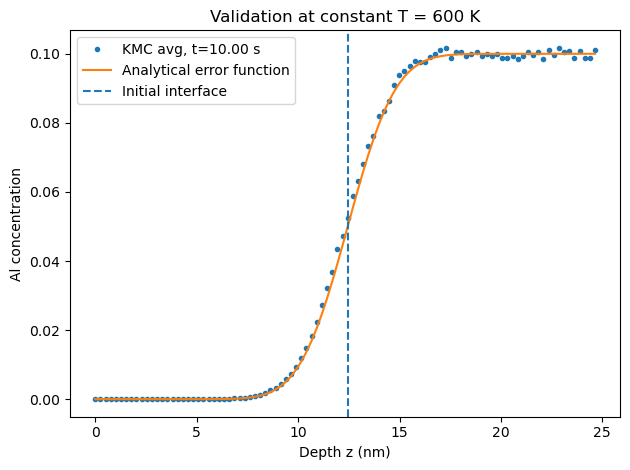

In [3]:
# Physical parameters
thickness_total = 25e-9   # m

# Lattice size
Nz = int(round(thickness_total / b))     # ~25 nm film
Nx = Nz

z_interface = Nz // 2
c_Al_init = 0.10

rng = np.random.default_rng(seed=12345)

# Helper functions

def D_of_T(T):
    return D0 * exp(-Q / (R * T))

def nu_of_T(T):
    # 2D random-walk mapping: D = nu * b^2
    D = D_of_T(T)
    return D / (b ** 2)

def init_lattice():
    """
    occ[z,x] in {0,1}  (0=Cu, 1=Al)
    al_sites: array of shape (N_Al, 2) with (z,x) of all Al atoms
    """
    occ = np.zeros((Nz, Nx), dtype=np.int8)
    mask = (rng.random((Nz - z_interface, Nx)) < c_Al_init)
    occ[z_interface:, :] = mask.astype(np.int8)

    al_sites = np.argwhere(occ == 1).astype(np.int32)
    return occ, al_sites

def concentration_profile(occ):
    return occ.mean(axis=1)


# KMC at constant temperature

def run_kmc_single_const(t_max, record_times, T_const):
    """
    Rejection KMC at constant temperature T_const.
    """
    occ, al_sites = init_lattice()
    N_al = al_sites.shape[0]

    t = 0.0
    record_times = np.asarray(record_times)
    rec_idx = 0

    profiles = []
    times_out = []

    # Recording initial
    while rec_idx < len(record_times) and t >= record_times[rec_idx]:
        profiles.append(concentration_profile(occ).copy())
        times_out.append(record_times[rec_idx])
        rec_idx += 1

    if N_al == 0:
        return np.array(times_out), np.array(profiles)

    nu = nu_of_T(T_const)
    Gamma = 4.0 * nu * N_al
    if Gamma <= 0.0:
        return np.array(times_out), np.array(profiles)

    while t < t_max:
        # Time step
        dt = -log(rng.random()) / Gamma
        t += dt

        # Pick random Al atom
        i_atom = rng.integers(N_al)
        z, x = al_sites[i_atom]

        # Pick random direction: 0=up, 1=down, 2=left, 3=right
        d = rng.integers(4)
        if d == 0:
            z2, x2 = z - 1, x
        elif d == 1:
            z2, x2 = z + 1, x
        elif d == 2:
            z2, x2 = z, (x - 1) % Nx
        else:
            z2, x2 = z, (x + 1) % Nx

        # Reflecting boundaries in z (no flux)
        if 0 <= z2 < Nz and occ[z2, x2] == 0:
            occ[z, x] = 0
            occ[z2, x2] = 1
            al_sites[i_atom, 0] = z2
            al_sites[i_atom, 1] = x2

        # Recording profiles when passing record times
        while rec_idx < len(record_times) and t >= record_times[rec_idx]:
            profiles.append(concentration_profile(occ).copy())
            times_out.append(record_times[rec_idx])
            rec_idx += 1

    return np.array(times_out), np.array(profiles)

def run_kmc_ensemble_const(n_runs, t_max, record_times, T_const):
    n_times = len(record_times)
    profiles_all = np.zeros((n_runs, n_times, Nz))

    for i in range(n_runs):
        print(f"Run {i+1}/{n_runs} ...")
        times, profiles = run_kmc_single_const(t_max, record_times, T_const)
        if profiles.shape[0] != n_times:
            last = profiles[-1]
            full = np.zeros((n_times, Nz))
            full[:profiles.shape[0]] = profiles
            full[profiles.shape[0]:] = last
            profiles = full
        profiles_all[i] = profiles

    return record_times, profiles_all.mean(axis=0), profiles_all


# Analytical error-function solution (for comparison)
def analytic_error_function_profile(z_indices, t, D, c_left, c_right, z_int):
    x = (z_indices - z_int) * b
    if t == 0:
        return np.where(z_indices < z_int, c_left, c_right)
    arg = x / (2.0 * sqrt(D * t))
    return 0.5*(c_left + c_right) - 0.5*(c_left - c_right)*erf(arg)


# CONSTANT TEMPERATURE VALIDATION
T_test = 600.0
D_test = D_of_T(T_test)

t_max_const = 10.0
record_times_const = np.linspace(0.0, t_max_const, 6)

n_runs_const = 1000

print("Running constant-T ensemble...")
times_const, prof_mean_const, _ = run_kmc_ensemble_const(
    n_runs=n_runs_const,
    t_max=t_max_const,
    record_times=record_times_const,
    T_const=T_test
)

t_compare = times_const[-1]
c_left = 0.0
c_right = 0.10

z_indices = np.arange(Nz)
z_physical_nm = z_indices * b * 1e9

c_analytic = analytic_error_function_profile(
    z_indices, t_compare, D_test, c_left, c_right, z_interface
)

plt.figure()
plt.plot(z_physical_nm, prof_mean_const[-1], "o", ms=3,
         label=f"KMC avg, t={t_compare:.2f} s")
plt.plot(z_physical_nm, c_analytic, "-", label="Analytical error function")
plt.axvline(z_interface*b*1e9, linestyle="--", label="Initial interface")
plt.xlabel("Depth z (nm)")
plt.ylabel("Al concentration")
plt.title("Validation at constant T = 600 K")
plt.legend()
plt.tight_layout()
plt.show()


Running constant-T ensemble...
Run 1/1000 ...
Run 2/1000 ...
Run 3/1000 ...
Run 4/1000 ...
Run 5/1000 ...
Run 6/1000 ...
Run 7/1000 ...
Run 8/1000 ...
Run 9/1000 ...
Run 10/1000 ...
Run 11/1000 ...
Run 12/1000 ...
Run 13/1000 ...
Run 14/1000 ...
Run 15/1000 ...
Run 16/1000 ...
Run 17/1000 ...
Run 18/1000 ...
Run 19/1000 ...
Run 20/1000 ...
Run 21/1000 ...
Run 22/1000 ...
Run 23/1000 ...
Run 24/1000 ...
Run 25/1000 ...
Run 26/1000 ...
Run 27/1000 ...
Run 28/1000 ...
Run 29/1000 ...
Run 30/1000 ...
Run 31/1000 ...
Run 32/1000 ...
Run 33/1000 ...
Run 34/1000 ...
Run 35/1000 ...
Run 36/1000 ...
Run 37/1000 ...
Run 38/1000 ...
Run 39/1000 ...
Run 40/1000 ...
Run 41/1000 ...
Run 42/1000 ...
Run 43/1000 ...
Run 44/1000 ...
Run 45/1000 ...
Run 46/1000 ...
Run 47/1000 ...
Run 48/1000 ...
Run 49/1000 ...
Run 50/1000 ...
Run 51/1000 ...
Run 52/1000 ...
Run 53/1000 ...
Run 54/1000 ...
Run 55/1000 ...
Run 56/1000 ...
Run 57/1000 ...
Run 58/1000 ...
Run 59/1000 ...
Run 60/1000 ...
Run 61/1000 ...
Ru

Run 497/1000 ...
Run 498/1000 ...
Run 499/1000 ...
Run 500/1000 ...
Run 501/1000 ...
Run 502/1000 ...
Run 503/1000 ...
Run 504/1000 ...
Run 505/1000 ...
Run 506/1000 ...
Run 507/1000 ...
Run 508/1000 ...
Run 509/1000 ...
Run 510/1000 ...
Run 511/1000 ...
Run 512/1000 ...
Run 513/1000 ...
Run 514/1000 ...
Run 515/1000 ...
Run 516/1000 ...
Run 517/1000 ...
Run 518/1000 ...
Run 519/1000 ...
Run 520/1000 ...
Run 521/1000 ...
Run 522/1000 ...
Run 523/1000 ...
Run 524/1000 ...
Run 525/1000 ...
Run 526/1000 ...
Run 527/1000 ...
Run 528/1000 ...
Run 529/1000 ...
Run 530/1000 ...
Run 531/1000 ...
Run 532/1000 ...
Run 533/1000 ...
Run 534/1000 ...
Run 535/1000 ...
Run 536/1000 ...
Run 537/1000 ...
Run 538/1000 ...
Run 539/1000 ...
Run 540/1000 ...
Run 541/1000 ...
Run 542/1000 ...
Run 543/1000 ...
Run 544/1000 ...
Run 545/1000 ...
Run 546/1000 ...
Run 547/1000 ...
Run 548/1000 ...
Run 549/1000 ...
Run 550/1000 ...
Run 551/1000 ...
Run 552/1000 ...
Run 553/1000 ...
Run 554/1000 ...
Run 555/1000 .

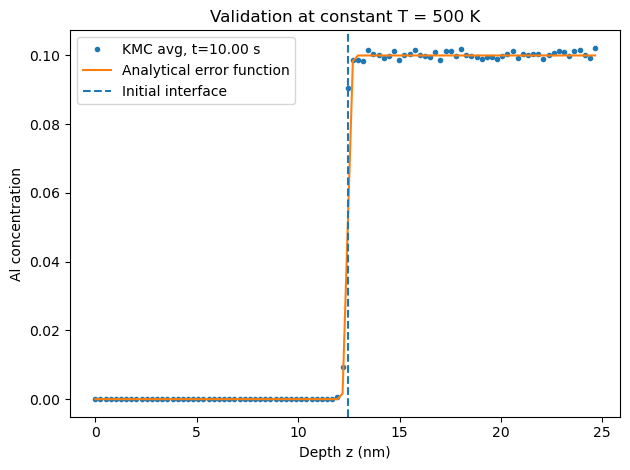

In [4]:
# Physical parameters
thickness_total = 25e-9   # m

# Lattice size
Nz = int(round(thickness_total / b))     # ~25 nm film
Nx = Nz

z_interface = Nz // 2
c_Al_init = 0.10

rng = np.random.default_rng(seed=12345)

# Helper functions

def D_of_T(T):
    return D0 * exp(-Q / (R * T))

def nu_of_T(T):
    # 2D random-walk mapping: D = nu * b^2
    D = D_of_T(T)
    return D / (b ** 2)

def init_lattice():
    """
    occ[z,x] in {0,1}  (0=Cu, 1=Al)
    al_sites: array of shape (N_Al, 2) with (z,x) of all Al atoms
    """
    occ = np.zeros((Nz, Nx), dtype=np.int8)
    mask = (rng.random((Nz - z_interface, Nx)) < c_Al_init)
    occ[z_interface:, :] = mask.astype(np.int8)

    al_sites = np.argwhere(occ == 1).astype(np.int32)
    return occ, al_sites

def concentration_profile(occ):
    return occ.mean(axis=1)


# KMC at constant temperature

def run_kmc_single_const(t_max, record_times, T_const):
    """
    Rejection KMC at constant temperature T_const.
    """
    occ, al_sites = init_lattice()
    N_al = al_sites.shape[0]

    t = 0.0
    record_times = np.asarray(record_times)
    rec_idx = 0

    profiles = []
    times_out = []

    # Recording initial
    while rec_idx < len(record_times) and t >= record_times[rec_idx]:
        profiles.append(concentration_profile(occ).copy())
        times_out.append(record_times[rec_idx])
        rec_idx += 1

    if N_al == 0:
        return np.array(times_out), np.array(profiles)

    nu = nu_of_T(T_const)
    Gamma = 4.0 * nu * N_al
    if Gamma <= 0.0:
        return np.array(times_out), np.array(profiles)

    while t < t_max:
        # Time step
        dt = -log(rng.random()) / Gamma
        t += dt

        # Pick random Al atom
        i_atom = rng.integers(N_al)
        z, x = al_sites[i_atom]

        # Pick random direction: 0=up, 1=down, 2=left, 3=right
        d = rng.integers(4)
        if d == 0:
            z2, x2 = z - 1, x
        elif d == 1:
            z2, x2 = z + 1, x
        elif d == 2:
            z2, x2 = z, (x - 1) % Nx
        else:
            z2, x2 = z, (x + 1) % Nx

        # Reflecting boundaries in z (no flux)
        if 0 <= z2 < Nz and occ[z2, x2] == 0:
            occ[z, x] = 0
            occ[z2, x2] = 1
            al_sites[i_atom, 0] = z2
            al_sites[i_atom, 1] = x2

        # Recording profiles when passing record times
        while rec_idx < len(record_times) and t >= record_times[rec_idx]:
            profiles.append(concentration_profile(occ).copy())
            times_out.append(record_times[rec_idx])
            rec_idx += 1

    return np.array(times_out), np.array(profiles)

def run_kmc_ensemble_const(n_runs, t_max, record_times, T_const):
    n_times = len(record_times)
    profiles_all = np.zeros((n_runs, n_times, Nz))

    for i in range(n_runs):
        print(f"Run {i+1}/{n_runs} ...")
        times, profiles = run_kmc_single_const(t_max, record_times, T_const)
        if profiles.shape[0] != n_times:
            last = profiles[-1]
            full = np.zeros((n_times, Nz))
            full[:profiles.shape[0]] = profiles
            full[profiles.shape[0]:] = last
            profiles = full
        profiles_all[i] = profiles

    return record_times, profiles_all.mean(axis=0), profiles_all


# Analytical error-function solution (for comparison)
def analytic_error_function_profile(z_indices, t, D, c_left, c_right, z_int):
    x = (z_indices - z_int) * b
    if t == 0:
        return np.where(z_indices < z_int, c_left, c_right)
    arg = x / (2.0 * sqrt(D * t))
    return 0.5*(c_left + c_right) - 0.5*(c_left - c_right)*erf(arg)


# CONSTANT TEMPERATURE VALIDATION
T_test = 500.0
D_test = D_of_T(T_test)

t_max_const = 10.0
record_times_const = np.linspace(0.0, t_max_const, 6)

n_runs_const = 1000

print("Running constant-T ensemble...")
times_const, prof_mean_const, _ = run_kmc_ensemble_const(
    n_runs=n_runs_const,
    t_max=t_max_const,
    record_times=record_times_const,
    T_const=T_test
)

t_compare = times_const[-1]
c_left = 0.0
c_right = 0.10

z_indices = np.arange(Nz)
z_physical_nm = z_indices * b * 1e9

c_analytic = analytic_error_function_profile(
    z_indices, t_compare, D_test, c_left, c_right, z_interface
)

plt.figure()
plt.plot(z_physical_nm, prof_mean_const[-1], "o", ms=3,
         label=f"KMC avg, t={t_compare:.2f} s")
plt.plot(z_physical_nm, c_analytic, "-", label="Analytical error function")
plt.axvline(z_interface*b*1e9, linestyle="--", label="Initial interface")
plt.xlabel("Depth z (nm)")
plt.ylabel("Al concentration")
plt.title("Validation at constant T = 500 K")
plt.legend()
plt.tight_layout()
plt.show()

Running 2D coarse-grained KMC with temperature ramp...
2D coarse run 1/10 ...
2D coarse run 2/10 ...
2D coarse run 3/10 ...
2D coarse run 4/10 ...
2D coarse run 5/10 ...
2D coarse run 6/10 ...
2D coarse run 7/10 ...
2D coarse run 8/10 ...
2D coarse run 9/10 ...
2D coarse run 10/10 ...


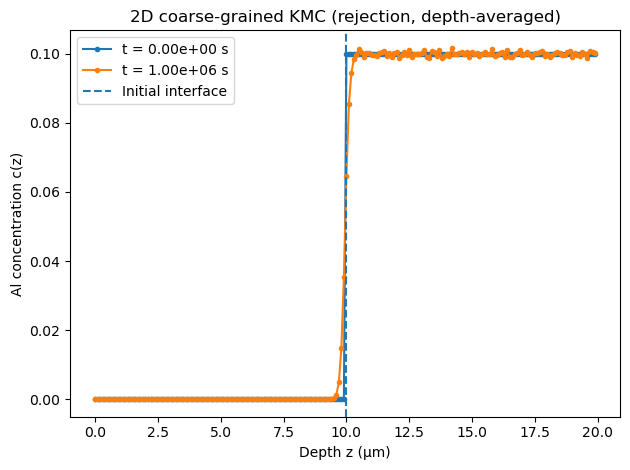

In [5]:
# Task 2.2

# Physical constants and Arrhenius parameters
R  = 8.314          # J/mol/K
D0 = 1.49e-7        # m^2/s
Q  = 137100.0       # J/mol

def D_of_T(T):
    return D0 * exp(-Q / (R * T))

# Geometry: 2 x 0.01 mm layers (depth z), lateral x
thickness_total = 2.0e-5   # m (2 x 0.01 mm)

Nz = 200                   # coarse cells in z
Nx = 200                    # coarse cells in x  (can change if you like)

Lz = thickness_total / Nz
Lx = Lz                    # square coarse cells for simplicity

# Interface at mid-depth: lower half Cu, upper half Cu-10%Al
cell_interface_z = Nz // 2

# Coarse-cell capacity and initial Al content
N_cell_sites = 100         # capacity per coarse cell
c_Al_init    = 0.10        # 10% Al in alloy half
n_init_alloy = int(round(c_Al_init * N_cell_sites))

# Total number of super-particles
N_super = Nx * (Nz - cell_interface_z) * n_init_alloy

rng = np.random.default_rng(12345)

# Temperature ramp
Ti = 298.0
Tf = 600.0
t_ramp = 1.0e6
t_max  = t_ramp

def T_of_t(t):
    if t >= t_ramp:
        return Tf
    return Ti + (Tf - Ti) * t / t_ramp

n_T_steps = 1000
dt_T = t_ramp / n_T_steps

# Initialization and helpers (2D)
def init_lattice_coarse():
    """
      - n[ix,iz]: occupancy (number of super-particles) in each cell
      - al_sites[k]: position (ix,iz) of super-particle k
    """
    n = np.zeros((Nx, Nz), dtype=np.int32)

    # Fill upper half with n_init_alloy per cell
    n[:, cell_interface_z:] = n_init_alloy

    # Build list of super-particles
    al_sites = np.zeros((N_super, 2), dtype=np.int32)
    idx = 0
    for ix in range(Nx):
        for iz in range(cell_interface_z, Nz):
            for _ in range(n_init_alloy):
                al_sites[idx, 0] = ix
                al_sites[idx, 1] = iz
                idx += 1

    return n, al_sites

# Depth-averaged concentration c(z) = <n(ix,z)>_x / N_cell_sites.
def depth_profile(n):
    return n.mean(axis=0).astype(float) / N_cell_sites

# Single 2D coarse-grained KMC trajectory
def run_kmc_single_2d(t_max, record_times):
    """
    2D coarse-grained KMC using rejection algorithm:

    - Γ = 4 * nu_hop * N_super (no blocked-site factor in Γ)
    - pick random super-particle and random direction each step
    - hops into full / out-of-bounds cells are rejected (null event)
    - T(t) handled with external time grid, piecewise-constant D(T)
    """
    n, al_sites = init_lattice_coarse()
    t = 0.0

    record_times = np.asarray(record_times)
    rec_idx = 0
    profiles = []
    times_out = []

    # Temperature interval bookkeeping
    t_T = 0.0
    t_T_next = min(dt_T, t_max)
    T = T_of_t(t_T)

    # Record initial state if needed
    while rec_idx < len(record_times) and t >= record_times[rec_idx]:
        profiles.append(depth_profile(n).copy())
        times_out.append(record_times[rec_idx])
        rec_idx += 1

    while t < t_max:
        # Hop rate from D(T)
        D = D_of_T(T)
        nu_hop = D / (Lz * Lz)

        # Total rate using rejection
        Gamma = 4.0 * nu_hop * N_super

        if Gamma <= 0.0:
            t = min(t_T_next, t_max)
        else:
            # Propose KMC event time
            dt_event = -log(rng.random()) / Gamma

            if t + dt_event > t_T_next:
                # No event in this temperature interval
                t = t_T_next
            else:
                # Perform event at time t + dt_event
                t += dt_event

                # Pick random super-particle
                k = rng.integers(N_super)
                ix, iz = al_sites[k]

                # Random direction: 0=left,1=right,2=down(z-),3=up(z+)
                d = rng.integers(4)
                if d == 0:
                    jx, jz = (ix - 1) % Nx, iz
                elif d == 1:
                    jx, jz = (ix + 1) % Nx, iz
                elif d == 2:
                    jx, jz = ix, iz - 1
                else:
                    jx, jz = ix, iz + 1

                # Reflecting boundaries in z, blocked site via rejection
                if 0 <= jz < Nz and n[jx, jz] < N_cell_sites:
                    # accept hop
                    n[ix, iz] -= 1
                    n[jx, jz] += 1
                    al_sites[k, 0] = jx
                    al_sites[k, 1] = jz
                # Else: null event (time still advanced)

        # Handling the crossing of temperature-grid boundary
        if t >= t_T_next and t < t_max:
            t_T = t_T_next
            t_T_next = min(t_T + dt_T, t_max)
            T = T_of_t(t_T)

        # Recording whenever we pass a record time
        while rec_idx < len(record_times) and t >= record_times[rec_idx]:
            profiles.append(depth_profile(n).copy())
            times_out.append(record_times[rec_idx])
            rec_idx += 1

    return np.array(times_out), np.array(profiles), n

# Ensemble driver
def run_kmc_ensemble_2d(n_runs, t_max, record_times):
    n_times = len(record_times)
    profiles_all = np.zeros((n_runs, n_times, Nz))

    for r in range(n_runs):
        print(f"2D coarse run {r+1}/{n_runs} ...")
        times, prof, _ = run_kmc_single_2d(t_max, record_times)
        if prof.shape[0] != n_times:
            last = prof[-1]
            full = np.zeros((n_times, Nz))
            full[:prof.shape[0]] = prof
            full[prof.shape[0]:] = last
            prof = full
        profiles_all[r] = prof

    return record_times, profiles_all.mean(axis=0), profiles_all

# Run and plot
if __name__ == "__main__":
    n_record = 21
    record_times_ramp = np.linspace(0.0, t_max, n_record)
    n_runs_ramp = 10

    print("Running 2D coarse-grained KMC with temperature ramp...")
    times_ramp, prof_mean_ramp, _ = run_kmc_ensemble_2d(
        n_runs=n_runs_ramp,
        t_max=t_max,
        record_times=record_times_ramp,
    )

    # Depth in micrometres
    z_cells = np.arange(Nz)
    z_physical_um = z_cells * Lz * 1e6

    plt.figure()
    plt.plot(z_physical_um, prof_mean_ramp[0], "-o", ms=3,
             label=f"t = {times_ramp[0]:.2e} s")
    plt.plot(z_physical_um, prof_mean_ramp[-1], "-o", ms=3,
             label=f"t = {times_ramp[-1]:.2e} s")
    plt.axvline(cell_interface_z * Lz * 1e6,
                linestyle="--", label="Initial interface")
    plt.xlabel("Depth z (µm)")
    plt.ylabel("Al concentration c(z)")
    plt.title("2D coarse-grained KMC (rejection, depth-averaged)")
    plt.legend()
    plt.tight_layout()
    plt.show()


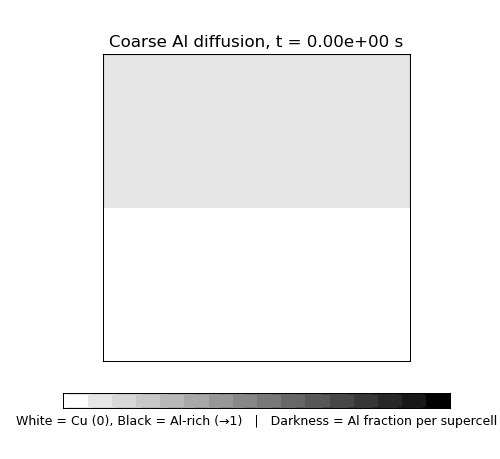

In [6]:
def run_kmc_single_2d_snapshots(t_max, snapshot_times):
    n, al_sites = init_lattice_coarse()
    t = 0.0

    snapshot_times = np.asarray(snapshot_times)
    snap_idx = 0
    snapshots = []
    times_out = []

    # Same as run_kmc_single_2d
    t_T = 0.0
    t_T_next = min(dt_T, t_max)
    T = T_of_t(t_T)

    while snap_idx < len(snapshot_times) and t >= snapshot_times[snap_idx]:
        snapshots.append(n.copy())
        times_out.append(snapshot_times[snap_idx])
        snap_idx += 1

    while t < t_max:
        D = D_of_T(T)
        nu_hop = D / (Lz * Lz)
        Gamma = 4.0 * nu_hop * N_super

        if Gamma <= 0.0:
            t = min(t_T_next, t_max)
        else:
            dt_event = -log(rng.random()) / Gamma

            if t + dt_event > t_T_next:
                t = t_T_next
            else:
                t += dt_event
                k = rng.integers(N_super)
                ix, iz = al_sites[k]
                d = rng.integers(4)
                if d == 0:
                    jx, jz = (ix - 1) % Nx, iz
                elif d == 1:
                    jx, jz = (ix + 1) % Nx, iz
                elif d == 2:
                    jx, jz = ix, iz - 1
                else:
                    jx, jz = ix, iz + 1
                if 0 <= jz < Nz and n[jx, jz] < N_cell_sites:
                    n[ix, iz] -= 1
                    n[jx, jz] += 1
                    al_sites[k, 0] = jx
                    al_sites[k, 1] = jz

        if t >= t_T_next and t < t_max:
            t_T = t_T_next
            t_T_next = min(t_T + dt_T, t_max)
            T = T_of_t(t_T)

        while snap_idx < len(snapshot_times) and t >= snapshot_times[snap_idx]:
            snapshots.append(n.copy())
            times_out.append(snapshot_times[snap_idx])
            snap_idx += 1

    return np.array(times_out), snapshots

# Generating snapshots
n_frames = 40
snapshot_times = np.linspace(0.0, t_max, n_frames)

times_snap, snapshots_n = run_kmc_single_2d_snapshots(
    t_max=t_max,
    snapshot_times=snapshot_times
)

# Converting occupancies to 0–1 for black/white 
# Fractional (gray-scale, 0 to 1):
snapshots_bw = [(s / N_cell_sites).astype(float) for s in snapshots_n]

# Animation
fig2 = plt.figure(figsize=(5, 4.6))
gs = fig2.add_gridspec(2, 1, height_ratios=[20, 1])

ax2 = fig2.add_subplot(gs[0])
ax_note = fig2.add_subplot(gs[1])

im2 = ax2.imshow(
    snapshots_bw[0].T,
    origin="lower",
    cmap="gray_r",
    vmin=0,
    vmax=1,
    interpolation="nearest",
    aspect="equal"
)

ax2.set_xlim(-0.5, Nx - 0.5)
ax2.set_ylim(-0.5, Nz - 0.5)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(f"Coarse Al diffusion, t = {times_snap[0]:.2e} s")

# Annotation
ax_note.imshow(
    np.linspace(0, 1, 256).reshape(1, -1),
    cmap="gray_r",
    aspect="auto"
)
ax_note.set_xticks([])
ax_note.set_yticks([])
ax_note.set_xlabel(
    "White = Cu (0), Black = Al-rich (→1)   |   Darkness = Al fraction per supercell",
    fontsize=9
)

def update(frame):
    im2.set_data(snapshots_bw[frame].T)
    ax2.set_title(f"Coarse Al diffusion, t = {times_snap[frame]:.2e} s")
    return [im2]

ani = animation.FuncAnimation(
    fig2, update,
    frames=len(snapshots_bw),
    interval=120,
    blit=False,
    repeat=True
)

plt.close(fig2)

gif_path = "coarse_Al.gif"
ani.save(gif_path, writer="pillow", fps=8)

Image(filename=gif_path)


final simulated time t_now = 1000.0009908788485
number of recorded snapshots = 101
At t_now =  1000.0009908788485
  N_Aui = 0
  N_I   = 43
  Total Au_s super-particles = 9946


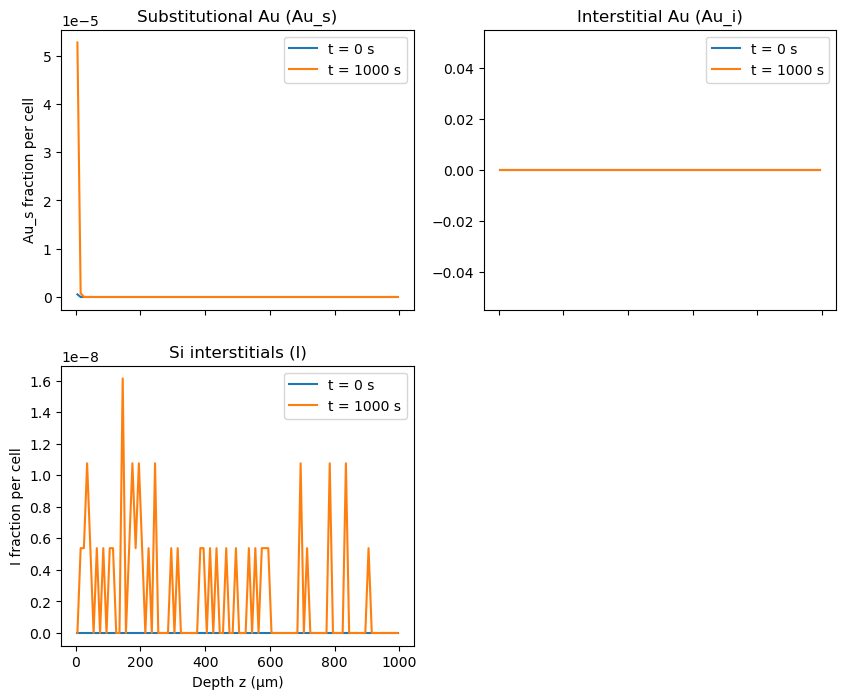

In [7]:
# Task 2.3

# Physical parameters
a_Si   = 5.4e-10        # m, lattice constant of Si
thick_z = 1.0e-3        # m, wafer thickness (z direction)
width_x = 1.0e-3        # m, lateral extent (x direction)
D      = 1e-9           # m^2/s, diffusivity of Au_i and I
k_f    = 600.0          # 1/s, forward kick-out rate
k_b    = 10.0           # 1/s, backward kick-out rate
c_eq_s = 5.38e-7        # equilibrium surface fraction of Au_s
t_end  = 1000.0         # s, annealing time

# 2D coarse grid
Nx = 100                 # cells in x (lateral)
Nz = 100                 # cells in z (depth)
Lx = width_x / Nx       # m, cell size in x
Lz = thick_z / Nz       # m, cell size in z

# Single effective step size for random walk
L = 0.5 * (Lx + Lz)
nu_hop = D / L**2       # per-neighbour hop rate for Au_i and I

# Occupancy scaling: "super-particles"
# Choosing N_sc so that 1 super-particle corresponds to c_eq_s in a cell
N_sc = int(round(1.0 / c_eq_s))   # capacity (number of "sites") per cell

# State arrays: integer numbers of super-particles per cell
n_Aui = np.zeros((Nx, Nz), dtype=int)   # Au interstitials (count of super-particles)
n_Aus = np.zeros((Nx, Nz), dtype=int)   # Au substitutionals
n_I   = np.zeros((Nx, Nz), dtype=int)   # Si interstitials

# Left surface at z=0 starts at equilibrium Au_s
n_Aus[:, 0] = 1                         # 1 / N_sc ≈ c_eq_s in all x

# Particle lists (super-particles)
# each entry is [ix, iz]
Aui_list = []        # list of Au_i super-particles
I_list   = []        # list of Si interstitial super-particles

# No initial Au_i: Au enters via injection from surface

# Removing particle k from p_list by swap-with-last
def delete_particle(p_list, k):
    last = len(p_list) - 1
    if k != last:
        p_list[k] = p_list[last]
    p_list.pop()

# Recording
times = []
profiles_Aus = []   # depth profiles (averaged over x)
profiles_Aui = []
profiles_I   = []

snapshots_Aus = []  # full 2D fields
snapshots_Aui = []
snapshots_I   = []

# Recording depth-averaged profiles and full 2D snapshots at time t
def record(t):
    times.append(t)
    profiles_Aus.append(n_Aus.mean(axis=0) / N_sc)
    profiles_Aui.append(n_Aui.mean(axis=0) / N_sc)
    profiles_I.append(  n_I.mean(axis=0)   / N_sc)

    snapshots_Aus.append(n_Aus.copy() / N_sc)
    snapshots_Aui.append(n_Aui.copy() / N_sc)
    snapshots_I.append(  n_I.copy()   / N_sc)

# Initial record
record(0.0)

# KMC parameters
rng = np.random.default_rng(123)
t_now = 0.0

sample_dt = 10.0        # record every 10 s of physical time
t_next = sample_dt

# Continuous Au_i injection flux at left surface
J_inj = 0.1             # 1/s per x-cell (tunable)

# Convenience constants for per-particle rates
Gamma_Aui_single = 4.0 * nu_hop + k_f
Gamma_I_single   = 4.0 * nu_hop + k_b

# KMC loop (rejection-style, particle based)
while t_now < t_end:

    # recording at fixed wall-clock intervals
    while t_next <= t_now and t_next <= t_end:
        record(t_next)
        t_next += sample_dt

    N_Aui = len(Aui_list)
    N_I   = len(I_list)

    Gamma_inj  = Nx * J_inj
    Gamma_Aui  = N_Aui * Gamma_Aui_single
    Gamma_I    = N_I   * Gamma_I_single
    R_tot      = Gamma_inj + Gamma_Aui + Gamma_I

    if R_tot <= 0.0:
        # nothing more can happen
        break

    # time increment
    dt = rng.exponential(1.0 / R_tot)
    t_now += dt
    if t_now > t_end:
        break

    # selecting which type of event
    r = rng.random() * R_tot

    # Injection event
    if r < Gamma_inj:
        # injecting Au_i at surface z=0 at random x
        ix = rng.integers(Nx)
        iz = 0
        Aui_list.append([ix, iz])
        n_Aui[ix, iz] += 1

    # Au_i diffusion / forward reaction
    elif r < Gamma_inj + Gamma_Aui and N_Aui > 0:

        r2 = r - Gamma_inj
        k = int(r2 / Gamma_Aui_single)
        if k >= N_Aui:
            k = N_Aui - 1

        ix, iz = Aui_list[k]

        # deciding between hop and forward reaction
        p_hop = 4.0 * nu_hop / Gamma_Aui_single
        if rng.random() < p_hop:
            # diffusion hop: choosing random direction
            d = rng.integers(4)
            if d == 0:         # left x
                jx, jz = (ix - 1) % Nx, iz
            elif d == 1:       # right x
                jx, jz = (ix + 1) % Nx, iz
            elif d == 2:       # down in z
                jx, jz = ix, iz - 1
            else:              # up in z
                jx, jz = ix, iz + 1

            # z-boundary: physical surfaces -> sinks for Au_i
            if jz < 0 or jz >= Nz:
                # sink: remove this Au_i
                n_Aui[ix, iz] -= 1
                delete_particle(Aui_list, k)
            else:
                # hop inside wafer
                n_Aui[ix, iz] -= 1
                n_Aui[jx, jz] += 1
                Aui_list[k] = [jx, jz]

        else:
            # forward kick-out: Au_i + Si_s -> Au_s + I
            # (Si_s reservoir implicit; only Au_s, I tracked)
            n_Aui[ix, iz] -= 1
            n_Aus[ix, iz] += 1
            delete_particle(Aui_list, k)

            # creating new Si interstitial I at same cell
            I_list.append([ix, iz])
            n_I[ix, iz] += 1

    # I diffusion / backward reaction
    elif N_I > 0:

        r3 = r - (Gamma_inj + Gamma_Aui)
        k = int(r3 / Gamma_I_single)
        if k >= N_I:
            k = N_I - 1

        ix, iz = I_list[k]

        p_hop_I = 4.0 * nu_hop / Gamma_I_single
        if rng.random() < p_hop_I:
            # diffusion hop of I
            d = rng.integers(4)
            if d == 0:
                jx, jz = (ix - 1) % Nx, iz
            elif d == 1:
                jx, jz = (ix + 1) % Nx, iz
            elif d == 2:
                jx, jz = ix, iz - 1
            else:
                jx, jz = ix, iz + 1

            # z-boundary: sinks for I
            if jz < 0 or jz >= Nz:
                n_I[ix, iz] -= 1
                delete_particle(I_list, k)
            else:
                n_I[ix, iz] -= 1
                n_I[jx, jz] += 1
                I_list[k] = [jx, jz]

        else:
            # backward kick-out attempt:
            # Au_s + I -> Au_i + Si_s
            # true rate per I is k_b * (n_Aus / N_sc)
            n_Aus_cell = n_Aus[ix, iz]
            if n_Aus_cell > 0:
                f_Aus = n_Aus_cell / float(N_sc)
                # rejection step to implement factor f_Aus
                if rng.random() < f_Aus:
                    # performing backward reaction
                    n_Aus[ix, iz] -= 1
                    n_I[ix, iz]   -= 1
                    delete_particle(I_list, k)

                    # creating new Au_i in same cell
                    Aui_list.append([ix, iz])
                    n_Aui[ix, iz] += 1
            # else: null event (no Au_s here), only time advanced

# final record at nominal annealing time
record(t_end)

print("final simulated time t_now =", t_now)
print("number of recorded snapshots =", len(times))

# Plot depth-averaged profiles
z = (np.arange(Nz) + 0.5) * Lz * 1e6   # depth in micrometers

c_Aus_0  = profiles_Aus[0]
c_Aus_f  = profiles_Aus[-1]
c_Aui_0  = profiles_Aui[0]
c_Aui_f  = profiles_Aui[-1]
c_I_0    = profiles_I[0]
c_I_f    = profiles_I[-1]
c_Au_tot_0 = c_Aus_0 + c_Aui_0
c_Au_tot_f = c_Aus_f + c_Aui_f

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
ax1, ax2, ax3, ax4 = axes.ravel()

# Removing the unused 4th subplot:
fig.delaxes(ax4)


# Au_s
ax1.plot(z, c_Aus_0,  label="t = 0 s")
ax1.plot(z, c_Aus_f,  label=f"t = {t_end:.0f} s")
ax1.set_ylabel("Au_s fraction per cell")
ax1.set_title("Substitutional Au (Au_s)")
ax1.legend()

# Au_i
ax2.plot(z, c_Aui_0,  label="t = 0 s")
ax2.plot(z, c_Aui_f,  label=f"t = {t_end:.0f} s")
ax2.set_title("Interstitial Au (Au_i)")
ax2.legend()

# I (Si interstitials)
ax3.plot(z, c_I_0,    label="t = 0 s")
ax3.plot(z, c_I_f,    label=f"t = {t_end:.0f} s")
ax3.set_xlabel("Depth z (µm)")
ax3.set_ylabel("I fraction per cell")
ax3.set_title("Si interstitials (I)")
ax3.legend()


print("At t_now = ", t_now)
print("  N_Aui =", len(Aui_list))
print("  N_I   =", len(I_list))
print("  Total Au_s super-particles =", n_Aus.sum())


MovieWriter imagemagick unavailable; using Pillow instead.


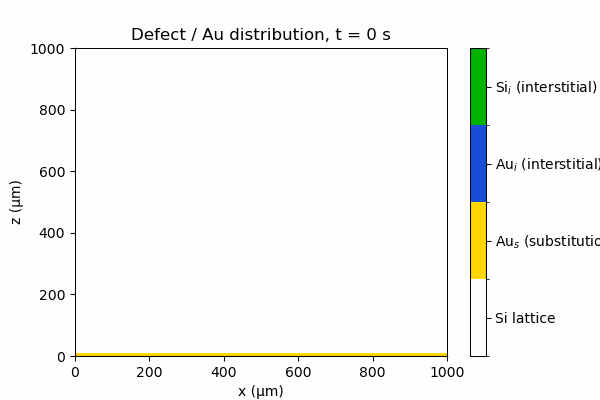

In [8]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# Stackicg snapshots into arrays and build 4-species map
snapshots_Aus = np.asarray(snapshots_Aus)   # shape (Nt, Nx, Nz)
snapshots_Aui = np.asarray(snapshots_Aui)   # shape (Nt, Nx, Nz)
snapshots_I   = np.asarray(snapshots_I)     # shape (Nt, Nx, Nz)

Nt, Nx_arr, Nz_arr = snapshots_Aus.shape
assert Nx_arr == Nx and Nz_arr == Nz

species = np.zeros_like(snapshots_Aus, dtype=np.uint8)
eps = 1e-12   # numerical tolerance

# 1 = Au_s
species[snapshots_Aus > eps] = 1

# 2 = Au_i  (overwrites Au_s if both present)
species[snapshots_Aui > eps] = 2

# 3 = Si_i (interstitial Si)  (overwrites both if present)
species[snapshots_I > eps]   = 3

# 2. Custom colormap: white, gold, blue, green
cmap_species = ListedColormap([
    (1.0, 1.0, 1.0),      # 0 → Si lattice (white)
    (1.0, 0.84, 0.0),     # 1 → Au_s (gold)
    (0.1, 0.3, 0.85),     # 2 → Au_i (blue)
    (0.0, 0.7, 0.0)       # 3 → Si_i (green)
])

bounds = [0, 1, 2, 3, 4]
norm = BoundaryNorm(bounds, cmap_species.N)

# 2D animation
fig2, ax2 = plt.subplots(figsize=(6, 4))

im2 = ax2.imshow(
    species[0].T,
    origin="lower",
    extent=[0, width_x * 1e6, 0, thick_z * 1e6],
    cmap=cmap_species,
    norm=norm,
    interpolation="nearest",
    aspect="auto"
)

# Categorical colorbar
cbar2 = plt.colorbar(im2, ax=ax2, ticks=[0.5, 1.5, 2.5, 3.5])
cbar2.ax.set_yticklabels([
    "Si lattice",
    "Au$_s$ (substitutional)",
    "Au$_i$ (interstitial)",
    "Si$_i$ (interstitial)"
])
cbar2.set_label("Local species type")

ax2.set_ylim(0, thick_z * 1e6)
ax2.set_xlabel("x (µm)")
ax2.set_ylabel("z (µm)")
ax2.set_title(f"Defect / Au distribution, t = {times[0]:.0f} s")

def update(frame):
    im2.set_data(species[frame].T)
    ax2.set_title(f"Defect / Au distribution, t = {times[frame]:.0f} s")
    return [im2]

ani = animation.FuncAnimation(
    fig2, update,
    frames=Nt,
    interval=120,
    blit=False,
    repeat=True
)

plt.close(fig2)

gif_path = "kickout_species_animation.gif"
ani.save(gif_path, writer="imagemagick", fps=8)

Image(filename=gif_path)
